In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("D:\Train Task\data\Dataset1.csv")
df.head()

<>:1: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
<>:1: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
C:\Users\Edwin Aldrin P\AppData\Local\Temp\ipykernel_11472\491829035.py:1: SyntaxWarning: "\T" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\T"? A raw string is also an option.
  df = pd.read_csv("D:\Train Task\data\Dataset1.csv")


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [11]:
df.shape

(186074, 12)

In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows: 186074
Columns: 12

Columns:
['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']

Data Types:
SN                int64
Train_No          int64
Station_Code        str
1A                int64
2A                int64
3A                int64
SL                int64
Station_Name        str
Route_Number      int64
Arrival_time        str
Departure_Time      str
Distance          int64
dtype: object

Missing Values:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

Duplicate Rows:
0


In [16]:
df_sorted = df.sort_values(["Train_No","SN"])

train_routes = df_sorted.groupby("Train_No").agg(
    Start_Station=("Station_Name","first"),
    End_Station=("Station_Name","last")
).reset_index()

train_routes.head(20)



,Train_No,Start_Station,End_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
5,421,LUCKNOW JN.,SHRI MATA VA
6,422,SHRI MATA VA,LUCKNOW JN.
7,477,SIRSA,SIRSA
8,502,RAJENDRANAGA,AMBALA CANTT
9,504,PATNA JN.,BATHINDA JN


In [21]:
train_routes.to_csv(
    "../outputs/tables/train_routes.csv",
    index=False
)

In [22]:
stops = df.groupby("Train_No").size().reset_index(name="Number_of_Stations")

stops["Number_of_Stops"]= stops["Number_of_Stations"] - 1

stops.head()

,Train_No,Number_of_Stations,Number_of_Stops
0,107,4,3
1,108,4,3
2,128,22,21
3,290,14,13
4,401,12,11


In [28]:
max_stops = stops["Number_of_Stops"].max()
min_stops = stops["Number_of_Stops"].min()

print("Maximum Stops:",max_stops)
print("Minimum Stops:",min_stops)

max_stops_trains= stops[
    stops["Number_of_Stops"] == max_stops
]

min_stops_trains= stops[
    stops["Number_of_Stops"] == min_stops
]

print(max_stops_trains)
print(min_stops_trains)

Maximum Stops: 117
Minimum Stops: 1
      Train_No  Number_of_Stations  Number_of_Stops
5977     53041                 118              117
       Train_No  Number_of_Stations  Number_of_Stops
11          557                   2                1
53         3305                   2                1
54         3306                   2                1
105        5715                   2                1
106        5716                   2                1
...         ...                 ...              ...
11064     99499                   2                1
11065     99500                   2                1
11066     99501                   2                1
11067     99502                   2                1
11068     99503                   2                1

[1249 rows x 3 columns]


In [ ]:
df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Arrival_Time_Clean"] = df["Arrival_time"].dt.time
df["Departure_Time_Clean"] = df["Departure_Time"].dt.time



In [38]:
%whos

Variable           Type         Data/Info
-----------------------------------------
classify_route     function     <function classify_route at 0x000002889858A350>
df                 DataFrame    Shape: (186074, 14)
df_sorted          DataFrame    Shape: (186074, 12)
max_stops          int64        117
max_stops_trains   DataFrame    Shape: (1, 3)
min_stops          int64        1
min_stops_trains   DataFrame    Shape: (1249, 3)
np                 module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd                 module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt                module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns                module       <module 'seaborn' from 'c<...>s\\seaborn\\__init__.py'>
stops              DataFrame    Shape: (11113, 3)
train_routes       DataFrame    Shape: (11113, 3)


In [39]:
df[["Train_No", "SN", "Station_Name", "Distance"]].head(20)

,Train_No,SN,Station_Name,Distance
0,107,1,SAWANTWADI R,0
1,107,2,THIVIM,32
2,107,3,KARMALI,49
3,107,4,MADGOAN JN.,78
4,108,1,MADGOAN JN.,0
5,108,2,KARMALI,33
6,108,3,THIVIM,51
7,108,4,SAWANTWADI R,83
8,128,1,MADGOAN JN.,0
9,128,2,KARMALI,33


In [47]:
train_distance = (
    df_sorted.groupby("Train_No")["Distance"]
    .last()
    .reset_index()
)
train_distance.head()




,Train_No,Distance
0,107,78
1,108,83
2,128,978
3,290,2694
4,401,1618


In [46]:
train_distance.shape

(11113, 2)

In [45]:
train_distance[
    train_distance["Train_No"] == 107
]

,Train_No,Distance
0,107,78


In [49]:
def classify_route(distance):
    if distance < 200:
        return "Short"
    elif distance <= 500:
        return "Medium"
    else:
        return "Long"

train_distance["Route_Type"] = train_distance["Distance"].apply(
    classify_route
)

In [51]:
train_distance.head()
train_distance["Route_Type"].value_counts()

Route_Type
Short     7628
Long      2204
Medium    1281
Name: count, dtype: int64

In [ ]:
station_frequency = (
    df.groupby(["Station_Code","Station_Name"])["Train_No"]
    .nunique()
    .reset_index(name="Train_Frequency")
)

station_frequency = station_frequency.sort_values(
    "Train_Frequency",
    ascending=False
)

station_frequency.head(10)


,Station_Code,Station_Name,Train_Frequency
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


In [58]:
df.isnull().sum()

SN                      0
Train_No                0
Station_Code            0
1A                      0
2A                      0
3A                      0
SL                      0
Station_Name            0
Route_Number            0
Arrival_time            0
Departure_Time          0
Distance                0
Arrival_Time_Clean      0
Departure_Time_Clean    0
dtype: int64

In [59]:
duplicate_rows = df.duplicated().sum()
print("Duplicate Records:",duplicate_rows)

Duplicate Records: 0


In [61]:
df = df.sort_values(["Train_No","SN"])

df["SN_Diff"] = df.groupby("Train_No")["SN"].diff()

invalid_sequence = df[
    (df["SN_Diff"].notna()) &
    (df["SN_Diff"] != 1)
]

invalid_sequence

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_Time_Clean,Departure_Time_Clean,SN_Diff
2308,35,6919,HOH,1240,1012,784,556,HONAGANAHALL,1,1900-01-01 12:33:00,1900-01-01 12:34:00,228,12:33:00,12:34:00,3.0
2317,8,6920,BSRX,315,272,229,186,BASAVANA BAG,1,1900-01-01 14:24:00,1900-01-01 14:25:00,43,14:24:00,14:25:00,3.0
135780,16,56905,BSRX,860,708,556,404,BASAVANA BAG,1,1900-01-01 08:04:00,1900-01-01 08:05:00,152,08:04:00,08:05:00,3.0
135835,31,56906,HOH,1240,1012,784,556,HONAGANAHALL,1,1900-01-01 19:06:00,1900-01-01 19:07:00,228,19:06:00,19:07:00,3.0
140416,21,57641,BSRX,860,708,556,404,BASAVANA BAG,1,1900-01-01 15:14:00,1900-01-01 15:15:00,152,15:14:00,15:15:00,3.0


In [62]:
df["Distance_Diff"] = (
    df.groupby("Train_No")["Distance"].diff()
)

invalid_distance = df[
    (df["Distance_Diff"] < 0)
]

invalid_distance

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_Time_Clean,Departure_Time_Clean,SN_Diff,Distance_Diff


In [98]:
df.to_csv(
    "../data/train_cleaned.csv",
    
    index=False
)



In [81]:
train_duration = df_sorted.groupby("Train_No").agg(
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last")
).reset_index()

In [88]:
train_duration["Start_Time"] = pd.to_datetime(
    train_duration["Start_Time"].astype(str),
    format="%H:%M:%S"
)

train_duration["End_Time"] = pd.to_datetime(
    train_duration["End_Time"].astype(str),
    format="%H:%M:%S"
)

In [89]:
train_duration.dtypes

Train_No               int64
Start_Time    datetime64[us]
End_Time      datetime64[us]
dtype: object

In [90]:
train_duration["Start_Minutes"] = (
    train_duration["Start_Time"].dt.hour * 60
    + train_duration["Start_Time"].dt.minute
    + train_duration["Start_Time"].dt.second / 60
)

train_duration["End_Minutes"] = (
    train_duration["End_Time"].dt.hour * 60
    + train_duration["End_Time"].dt.minute
    + train_duration["End_Time"].dt.second / 60
)

In [91]:
train_duration.head()

,Train_No,Start_Time,End_Time,Start_Minutes,End_Minutes
0,107,1900-01-01 10:25:00,1900-01-01 12:10:00,625.0,730.0
1,108,1900-01-01 20:30:00,1900-01-01 22:25:00,1230.0,1345.0
2,128,1900-01-01 19:40:00,1900-01-01 17:45:00,1180.0,1065.0
3,290,1900-01-01 18:30:00,1900-01-01 02:30:00,1110.0,150.0
4,401,1900-01-01 21:30:00,1900-01-01 10:00:00,1290.0,600.0


In [92]:
train_duration["End_Minutes_Adjusted"] = np.where(
    train_duration["End_Minutes"] < train_duration["Start_Minutes"],
    train_duration["End_Minutes"] + 1440,
    train_duration["End_Minutes"]
)

In [93]:
train_duration["Journey_Duration_Hours"] = (
    train_duration["End_Minutes_Adjusted"]
    - train_duration["Start_Minutes"]
) / 60

In [94]:
train_duration.head()

,Train_No,Start_Time,End_Time,Start_Minutes,End_Minutes,End_Minutes_Adjusted,Journey_Duration_Hours
0,107,1900-01-01 10:25:00,1900-01-01 12:10:00,625.0,730.0,730.0,1.750000
1,108,1900-01-01 20:30:00,1900-01-01 22:25:00,1230.0,1345.0,1345.0,1.916667
2,128,1900-01-01 19:40:00,1900-01-01 17:45:00,1180.0,1065.0,2505.0,22.083333
3,290,1900-01-01 18:30:00,1900-01-01 02:30:00,1110.0,150.0,1590.0,8.000000
4,401,1900-01-01 21:30:00,1900-01-01 10:00:00,1290.0,600.0,2040.0,12.500000


In [95]:
train_summary = pd.merge(
    train_distance,
    train_duration[
        ["Train_No", "Start_Time", "End_Time", "Journey_Duration_Hours"]
    ],
    on="Train_No",
    how="inner"
)

In [96]:
train_summary = pd.merge(
    train_distance,
    train_duration[
        ["Train_No", "Start_Time", "End_Time", "Journey_Duration_Hours"]
    ],
    on="Train_No",
    how="inner"
)

In [99]:
train_summary.shape

(11113, 6)

In [104]:
train_summary.head()

,Train_No,Distance,Route_Type,Start_Time,End_Time,Journey_Duration_Hours
0,107,78,Short,1900-01-01 10:25:00,1900-01-01 12:10:00,1.750000
1,108,83,Short,1900-01-01 20:30:00,1900-01-01 22:25:00,1.916667
2,128,978,Long,1900-01-01 19:40:00,1900-01-01 17:45:00,22.083333
3,290,2694,Long,1900-01-01 18:30:00,1900-01-01 02:30:00,8.000000
4,401,1618,Long,1900-01-01 21:30:00,1900-01-01 10:00:00,12.500000


In [105]:
train_summary.info()


<class 'pandas.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Train_No                11113 non-null  int64         
 1   Distance                11113 non-null  int64         
 2   Route_Type              11113 non-null  str           
 3   Start_Time              11113 non-null  datetime64[us]
 4   End_Time                11113 non-null  datetime64[us]
 5   Journey_Duration_Hours  11113 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 574.4 KB


In [106]:
train_summary.describe()

,Train_No,Distance,Start_Time,End_Time,Journey_Duration_Hours
count,11113.000000,11113.000000,11113,11113,11113.000000
mean,49190.570413,348.870242,1900-01-01 13:17:37.933952,1900-01-01 13:44:35.812112,4.600225
min,107.000000,1.000000,1900-01-01 00:01:00,1900-01-01 00:00:00,0.000000
25%,22607.000000,38.000000,1900-01-01 08:08:00,1900-01-01 09:10:00,1.016667
50%,47174.000000,82.000000,1900-01-01 13:40:00,1900-01-01 13:25:00,2.200000
75%,68012.000000,324.000000,1900-01-01 18:05:00,1900-01-01 19:00:00,6.083333
max,99908.000000,4260.000000,1900-01-01 23:59:00,1900-01-01 23:59:00,23.916667
std,28515.986645,596.179751,NaN,NaN,5.352782


In [107]:
avg_duration_by_route = (
    train_summary
    .groupby("Route_Type")["Journey_Duration_Hours"]
    .mean()
    .reset_index()
)

avg_duration_by_route

,Route_Type,Journey_Duration_Hours
0,Long,12.504492
1,Medium,7.746617
2,Short,1.788016


In [108]:
avg_duration_by_route = avg_duration_by_route.sort_values(
    "Journey_Duration_Hours"
)

avg_duration_by_route

,Route_Type,Journey_Duration_Hours
2,Short,1.788016
1,Medium,7.746617
0,Long,12.504492


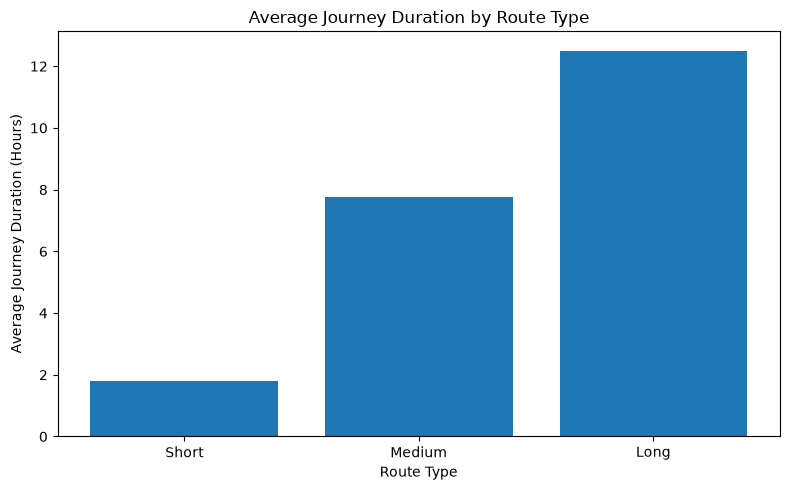

In [109]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_duration_by_route["Route_Type"],
    avg_duration_by_route["Journey_Duration_Hours"]
)

plt.title("Average Journey Duration by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Journey Duration (Hours)")

plt.tight_layout()
plt.show()

In [110]:
top_longest_journeys = (
    train_summary
    .sort_values("Journey_Duration_Hours", ascending=False)
    .head(10)
)

top_longest_journeys

,Train_No,Distance,Route_Type,Start_Time,End_Time,Journey_Duration_Hours
1723,15001,1122,Long,1900-01-01 14:00:00,1900-01-01 13:55:00,23.916667
1300,12949,2664,Long,1900-01-01 08:10:00,1900-01-01 08:05:00,23.916667
374,11103,1321,Long,1900-01-01 16:50:00,1900-01-01 16:45:00,23.916667
1128,12766,1305,Long,1900-01-01 06:45:00,1900-01-01 06:35:00,23.833333
888,12494,1501,Long,1900-01-01 21:35:00,1900-01-01 21:25:00,23.833333
252,8617,1365,Long,1900-01-01 14:05:00,1900-01-01 13:55:00,23.833333
1140,12778,1297,Long,1900-01-01 12:50:00,1900-01-01 12:40:00,23.833333
1139,12777,1295,Long,1900-01-01 06:45:00,1900-01-01 06:30:00,23.750000
406,11404,1026,Long,1900-01-01 12:50:00,1900-01-01 12:35:00,23.750000
2187,17214,1092,Long,1900-01-01 11:15:00,1900-01-01 11:00:00,23.750000


In [111]:
top_longest_journeys[
    [
        "Train_No",
        "Distance",
        "Route_Type",
        "Start_Time",
        "End_Time",
        "Journey_Duration_Hours"
    ]
]

,Train_No,Distance,Route_Type,Start_Time,End_Time,Journey_Duration_Hours
1723,15001,1122,Long,1900-01-01 14:00:00,1900-01-01 13:55:00,23.916667
1300,12949,2664,Long,1900-01-01 08:10:00,1900-01-01 08:05:00,23.916667
374,11103,1321,Long,1900-01-01 16:50:00,1900-01-01 16:45:00,23.916667
1128,12766,1305,Long,1900-01-01 06:45:00,1900-01-01 06:35:00,23.833333
888,12494,1501,Long,1900-01-01 21:35:00,1900-01-01 21:25:00,23.833333
252,8617,1365,Long,1900-01-01 14:05:00,1900-01-01 13:55:00,23.833333
1140,12778,1297,Long,1900-01-01 12:50:00,1900-01-01 12:40:00,23.833333
1139,12777,1295,Long,1900-01-01 06:45:00,1900-01-01 06:30:00,23.750000
406,11404,1026,Long,1900-01-01 12:50:00,1900-01-01 12:35:00,23.750000
2187,17214,1092,Long,1900-01-01 11:15:00,1900-01-01 11:00:00,23.750000


In [112]:
# Top 10 longest journeys

top_longest_journeys = (
    train_summary
    .sort_values("Journey_Duration_Hours", ascending=False)
    .head(10)
)

top_longest_journeys[
    [
        "Train_No",
        "Distance",
        "Route_Type",
        "Start_Time",
        "End_Time",
        "Journey_Duration_Hours"
    ]
]

,Train_No,Distance,Route_Type,Start_Time,End_Time,Journey_Duration_Hours
1723,15001,1122,Long,1900-01-01 14:00:00,1900-01-01 13:55:00,23.916667
1300,12949,2664,Long,1900-01-01 08:10:00,1900-01-01 08:05:00,23.916667
374,11103,1321,Long,1900-01-01 16:50:00,1900-01-01 16:45:00,23.916667
1128,12766,1305,Long,1900-01-01 06:45:00,1900-01-01 06:35:00,23.833333
888,12494,1501,Long,1900-01-01 21:35:00,1900-01-01 21:25:00,23.833333
252,8617,1365,Long,1900-01-01 14:05:00,1900-01-01 13:55:00,23.833333
1140,12778,1297,Long,1900-01-01 12:50:00,1900-01-01 12:40:00,23.833333
1139,12777,1295,Long,1900-01-01 06:45:00,1900-01-01 06:30:00,23.750000
406,11404,1026,Long,1900-01-01 12:50:00,1900-01-01 12:35:00,23.750000
2187,17214,1092,Long,1900-01-01 11:15:00,1900-01-01 11:00:00,23.750000


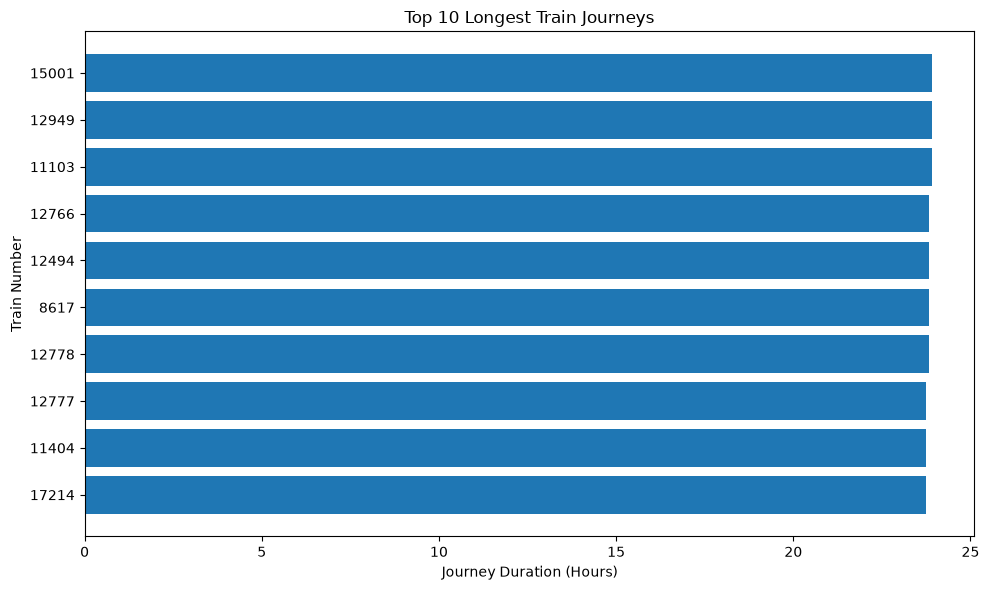

In [113]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_longest_journeys["Train_No"].astype(str),
    top_longest_journeys["Journey_Duration_Hours"]
)

plt.title("Top 10 Longest Train Journeys")
plt.xlabel("Journey Duration (Hours)")
plt.ylabel("Train Number")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [115]:
top_stations = (
    station_frequency
    .head(10)
    .copy()
)

top_stations[
    [
        "Station_Code",
        "Station_Name",
        "Train_Frequency"
    ]
]

,Station_Code,Station_Name,Train_Frequency
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


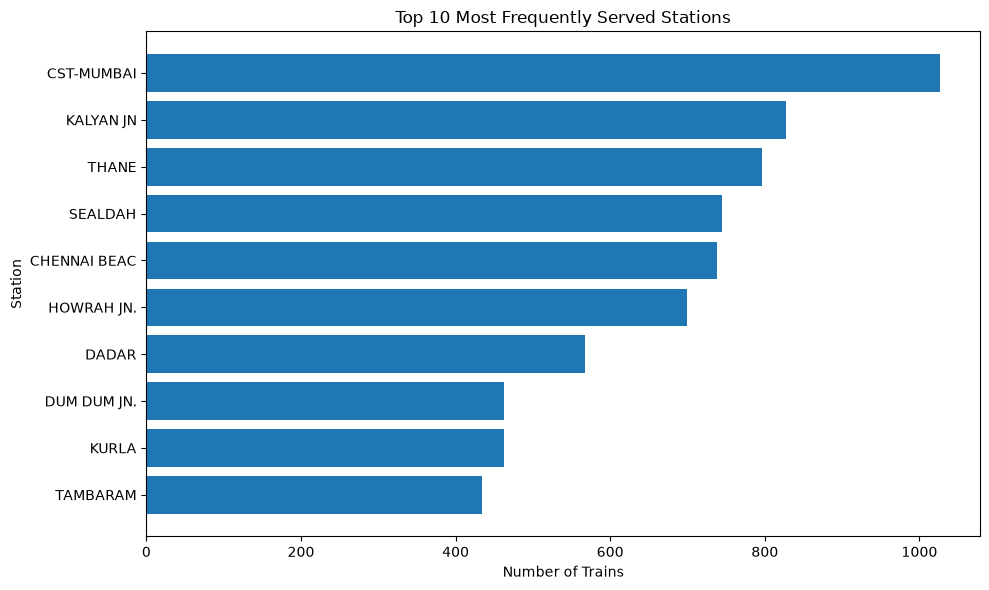

In [116]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_stations["Station_Name"],
    top_stations["Train_Frequency"]
)

plt.title("Top 10 Most Frequently Served Stations")
plt.xlabel("Number of Trains")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [117]:
route_distribution = (
    train_summary["Route_Type"]
    .value_counts()
    .reset_index()
)

route_distribution.columns = [
    "Route_Type",
    "Train_Count"
]

route_distribution

,Route_Type,Train_Count
0,Short,7628
1,Long,2204
2,Medium,1281


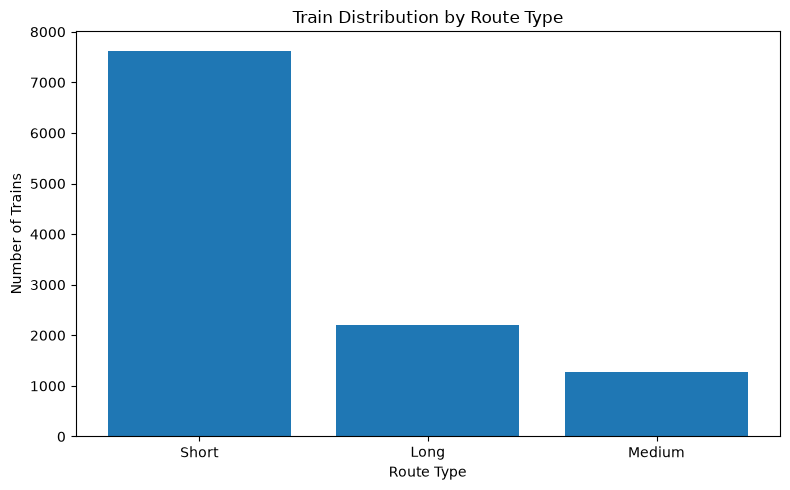

In [118]:
plt.figure(figsize=(8, 5))

plt.bar(
    route_distribution["Route_Type"],
    route_distribution["Train_Count"]
)

plt.title("Train Distribution by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Number of Trains")

plt.tight_layout()
plt.show()

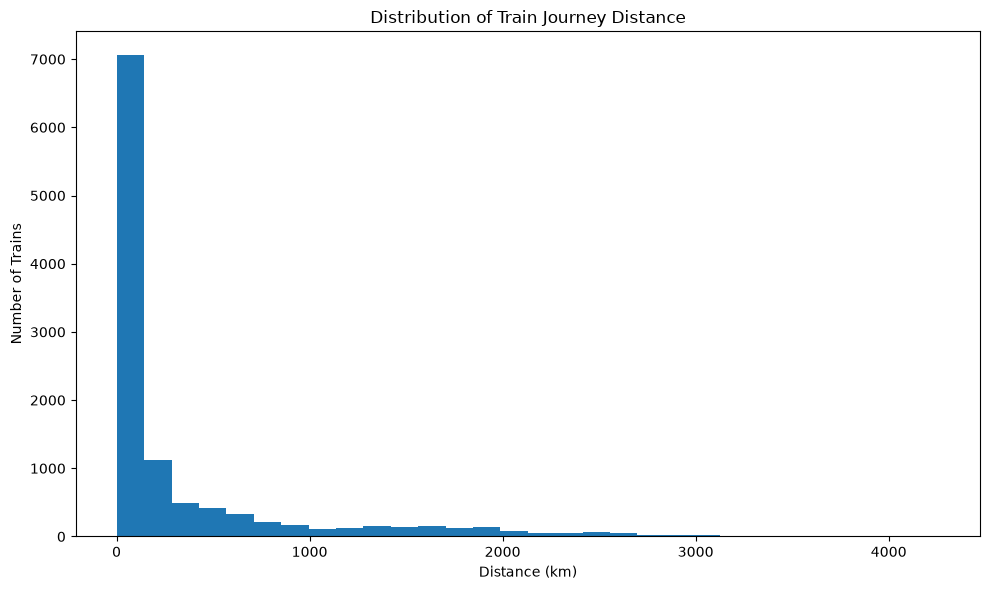

In [119]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_summary["Distance"],
    bins=30
)

plt.title("Distribution of Train Journey Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Trains")

plt.tight_layout()
plt.show()

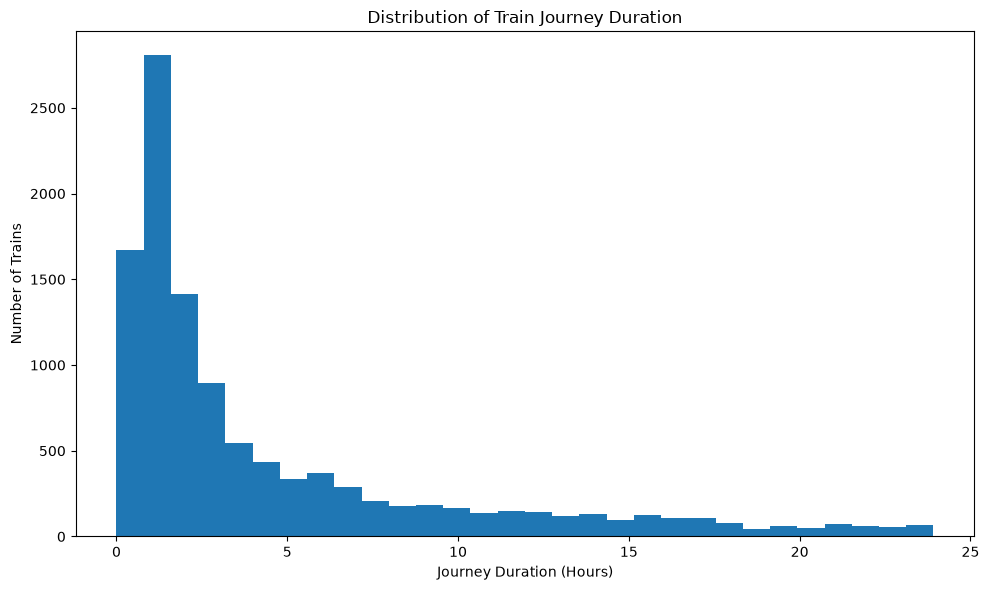

In [120]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_summary["Journey_Duration_Hours"],
    bins=30
)

plt.title("Distribution of Train Journey Duration")
plt.xlabel("Journey Duration (Hours)")
plt.ylabel("Number of Trains")

plt.tight_layout()
plt.show()

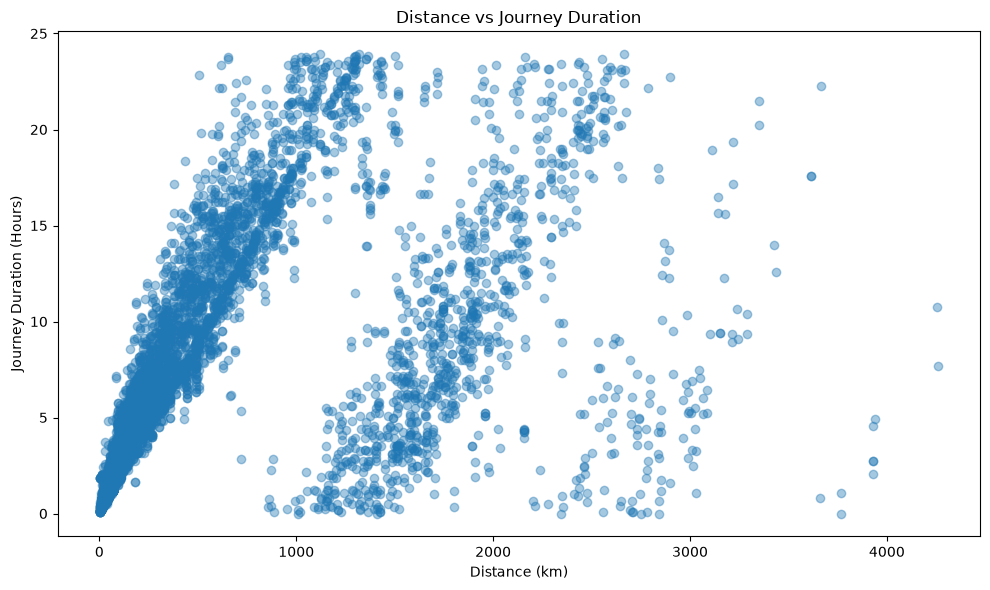

In [121]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_summary["Distance"],
    train_summary["Journey_Duration_Hours"],
    alpha=0.4
)

plt.title("Distance vs Journey Duration")
plt.xlabel("Distance (km)")
plt.ylabel("Journey Duration (Hours)")

plt.tight_layout()
plt.show()

In [122]:
avg_duration_by_route = (
    train_summary
    .groupby("Route_Type")["Journey_Duration_Hours"]
    .mean()
    .reset_index()
)

avg_duration_by_route = avg_duration_by_route.sort_values(
    "Journey_Duration_Hours"
)

avg_duration_by_route

,Route_Type,Journey_Duration_Hours
2,Short,1.788016
1,Medium,7.746617
0,Long,12.504492


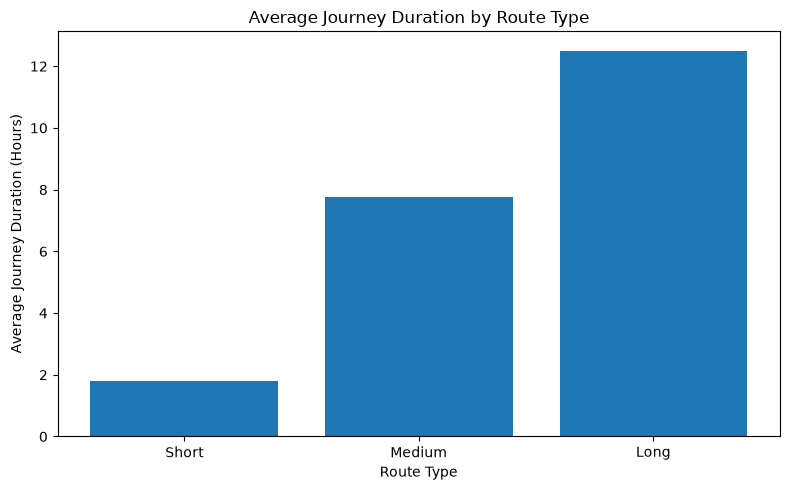

In [123]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_duration_by_route["Route_Type"],
    avg_duration_by_route["Journey_Duration_Hours"]
)

plt.title("Average Journey Duration by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Journey Duration (Hours)")

plt.tight_layout()
plt.show()

In [124]:
avg_distance_by_route = (
    train_summary
    .groupby("Route_Type")["Distance"]
    .mean()
    .reset_index()
)

avg_distance_by_route = avg_distance_by_route.sort_values(
    "Distance"
)

avg_distance_by_route

,Route_Type,Distance
2,Short,62.641846
1,Medium,321.395004
0,Long,1355.470054


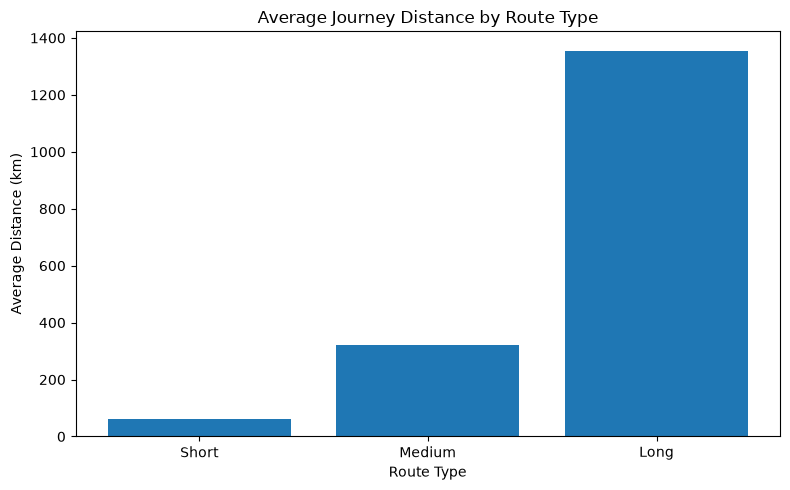

In [125]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_distance_by_route["Route_Type"],
    avg_distance_by_route["Distance"]
)

plt.title("Average Journey Distance by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Distance (km)")

plt.tight_layout()
plt.show()

In [126]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Trains",
        "Average Distance (km)",
        "Maximum Distance (km)",
        "Minimum Distance (km)",
        "Average Journey Duration (hours)",
        "Maximum Journey Duration (hours)",
        "Minimum Journey Duration (hours)"
    ],
    "Value": [
        train_summary["Train_No"].nunique(),
        train_summary["Distance"].mean(),
        train_summary["Distance"].max(),
        train_summary["Distance"].min(),
        train_summary["Journey_Duration_Hours"].mean(),
        train_summary["Journey_Duration_Hours"].max(),
        train_summary["Journey_Duration_Hours"].min()
    ]
})

eda_summary

,Metric,Value
0,Total Trains,11113.000000
1,Average Distance (km),348.870242
2,Maximum Distance (km),4260.000000
3,Minimum Distance (km),1.000000
4,Average Journey Duration (hours),4.600225
5,Maximum Journey Duration (hours),23.916667
6,Minimum Journey Duration (hours),0.000000


In [127]:
train_summary.to_csv(
    "../outputs/tables/train_summary.csv",
    index=False
)

avg_duration_by_route.to_csv(
    "../outputs/tables/avg_duration_by_route.csv",
    index=False
)

avg_distance_by_route.to_csv(
    "../outputs/tables/avg_distance_by_route.csv",
    index=False
)

top_longest_journeys.to_csv(
    "../outputs/tables/top_longest_journeys.csv",
    index=False
)

top_stations.to_csv(
    "../outputs/tables/top_stations.csv",
    index=False
)

route_distribution.to_csv(
    "../outputs/tables/route_distribution.csv",
    index=False
)

eda_summary.to_csv(
    "../outputs/tables/eda_summary.csv",
    index=False
)

In [128]:
train_summary.to_csv(
    "../outputs/tables/train_summary.csv",
    index=False
)

avg_duration_by_route.to_csv(
    "../outputs/tables/avg_duration_by_route.csv",
    index=False
)

avg_distance_by_route.to_csv(
    "../outputs/tables/avg_distance_by_route.csv",
    index=False
)

top_longest_journeys.to_csv(
    "../outputs/tables/top_longest_journeys.csv",
    index=False
)

top_stations.to_csv(
    "../outputs/tables/top_stations.csv",
    index=False
)

route_distribution.to_csv(
    "../outputs/tables/route_distribution.csv",
    index=False
)

eda_summary.to_csv(
    "../outputs/tables/eda_summary.csv",
    index=False
)

In [129]:
pivot_station = pd.pivot_table(
    df,
    index="Station_Name",
    values="Train_No",
    aggfunc="nunique"
)

pivot_station = pivot_station.sort_values(
    "Train_No",
    ascending=False
)

pivot_station.head(20)

,Train_No
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


In [130]:
pivot_station = pivot_station.rename(
    columns={"Train_No": "Train_Count"}
)

pivot_station.head(20)

,Train_Count
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


In [133]:
# Add Route_Type from train_summary to each station record

df_advanced = df.merge(
    train_summary[["Train_No", "Route_Type"]],
    on="Train_No",
    how="left"
)

df_advanced.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_Time_Clean,Departure_Time_Clean,SN_Diff,Distance_Diff,Route_Type
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,1900-01-01 10:25:00,0,00:00:00,10:25:00,NaN,NaN,Short
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,1900-01-01 11:08:00,32,11:06:00,11:08:00,1.0,32.0,Short
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,1900-01-01 11:30:00,49,11:28:00,11:30:00,1.0,17.0,Short
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,1900-01-01 00:00:00,78,12:10:00,00:00:00,1.0,29.0,Short
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,1900-01-01 20:30:00,0,00:00:00,20:30:00,NaN,NaN,Short


In [134]:
route_station_crosstab = pd.crosstab(
    df_advanced["Station_Name"],
    df_advanced["Route_Type"]
)

route_station_crosstab.head(20)

Route_Type,Long,Medium,Short
Station_Name,,,
.BAGHAJATIN,0,0,217
ABADA,1,0,89
ABHAIPUR,38,11,13
ABHANPUR JN.,0,0,12
ABHAYAPURI A,0,6,0
ABJUGANJ,0,0,6
ABOHAR,9,11,8
ABU ROAD,94,4,2
ABUTARA HALT,0,2,4


In [135]:
route_station_crosstab["Total_Trains"] = (
    route_station_crosstab.sum(axis=1)
)

route_station_crosstab = route_station_crosstab.sort_values(
    "Total_Trains",
    ascending=False
)

route_station_crosstab.head(20)

Route_Type,Long,Medium,Short,Total_Trains
Station_Name,,,,
CST-MUMBAI,83,11,933,1027
KALYAN JN,229,19,580,828
THANE,134,17,645,796
SEALDAH,42,24,679,745
CHENNAI BEAC,0,0,738,738
HOWRAH JN.,177,62,460,699
DADAR,100,25,473,598
DUM DUM JN.,2,14,447,463
KURLA,0,0,462,462


In [136]:
top_15_stations = (
    pivot_station
    .head(15)
    .reset_index()
)

top_15_stations

,Station_Name,Train_Count
0,CST-MUMBAI,1027
1,KALYAN JN,828
2,THANE,796
3,SEALDAH,745
4,CHENNAI BEAC,738
5,HOWRAH JN.,699
6,DADAR,598
7,DUM DUM JN.,463
8,KURLA,462
9,TAMBARAM,434


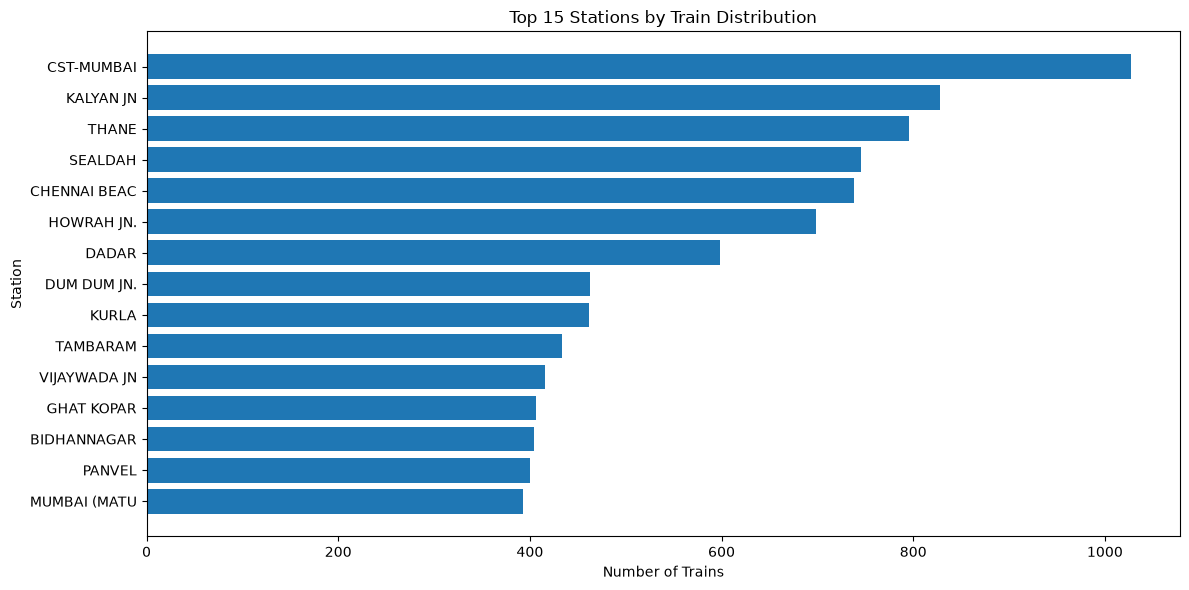

In [137]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_15_stations["Station_Name"],
    top_15_stations["Train_Count"]
)

plt.title("Top 15 Stations by Train Distribution")
plt.xlabel("Number of Trains")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [138]:
top_15_route_distribution = (
    route_station_crosstab
    .head(15)
    .drop(columns="Total_Trains")
)

top_15_route_distribution

Route_Type,Long,Medium,Short
Station_Name,,,
CST-MUMBAI,83,11,933
KALYAN JN,229,19,580
THANE,134,17,645
SEALDAH,42,24,679
CHENNAI BEAC,0,0,738
HOWRAH JN.,177,62,460
DADAR,100,25,473
DUM DUM JN.,2,14,447
KURLA,0,0,462


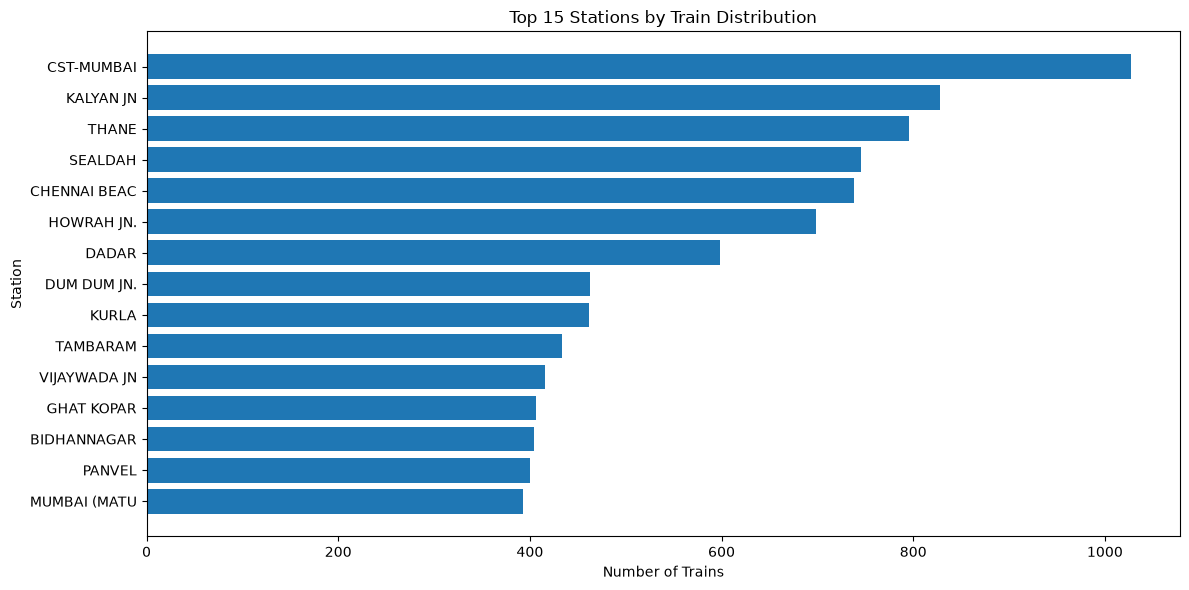

In [139]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_15_stations["Station_Name"],
    top_15_stations["Train_Count"]
)

plt.title("Top 15 Stations by Train Distribution")
plt.xlabel("Number of Trains")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [140]:
top_15_route_distribution = (
    route_station_crosstab
    .head(15)
    .drop(columns="Total_Trains")
)

top_15_route_distribution

Route_Type,Long,Medium,Short
Station_Name,,,
CST-MUMBAI,83,11,933
KALYAN JN,229,19,580
THANE,134,17,645
SEALDAH,42,24,679
CHENNAI BEAC,0,0,738
HOWRAH JN.,177,62,460
DADAR,100,25,473
DUM DUM JN.,2,14,447
KURLA,0,0,462


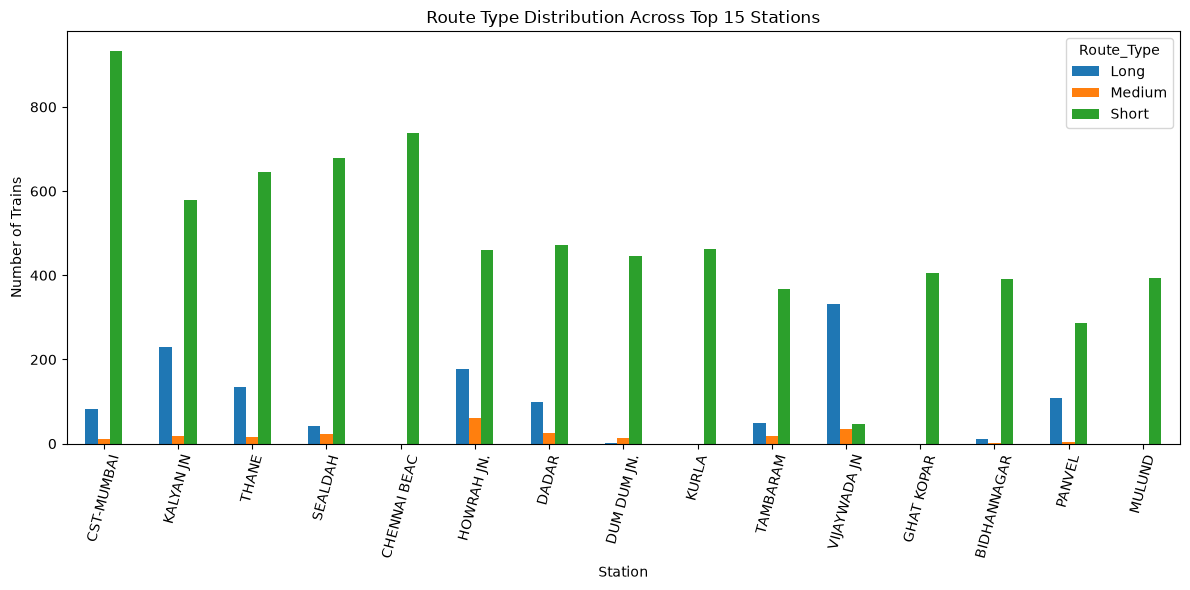

In [141]:
top_15_route_distribution.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Route Type Distribution Across Top 15 Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")

plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [142]:
station_route_analysis = route_station_crosstab.copy()

station_route_analysis["Long_Percentage"] = (
    station_route_analysis["Long"]
    / station_route_analysis["Total_Trains"]
) * 100

station_route_analysis.head()

Route_Type,Long,Medium,Short,Total_Trains,Long_Percentage
Station_Name,,,,,
CST-MUMBAI,83,11,933,1027,8.081792
KALYAN JN,229,19,580,828,27.657005
THANE,134,17,645,796,16.834171
SEALDAH,42,24,679,745,5.637584
CHENNAI BEAC,0,0,738,738,0.000000


In [143]:
top_long_route_stations = (
    station_route_analysis
    .sort_values(
        "Long_Percentage",
        ascending=False
    )
    .head(15)
)

top_long_route_stations

Route_Type,Long,Medium,Short,Total_Trains,Long_Percentage
Station_Name,,,,,
SATYAVALLI,1,0,0,1,100.0
UDRAMSAR,4,0,0,4,100.0
SONAUILM,1,0,0,1,100.0
AMBALA CANT JN,1,0,0,1,100.0
LADPURA,2,0,0,2,100.0
BESROLI,2,0,0,2,100.0
YESVANTPUR B,2,0,0,2,100.0
REGADIPALLI,2,0,0,2,100.0
CARANZOL,1,0,0,1,100.0


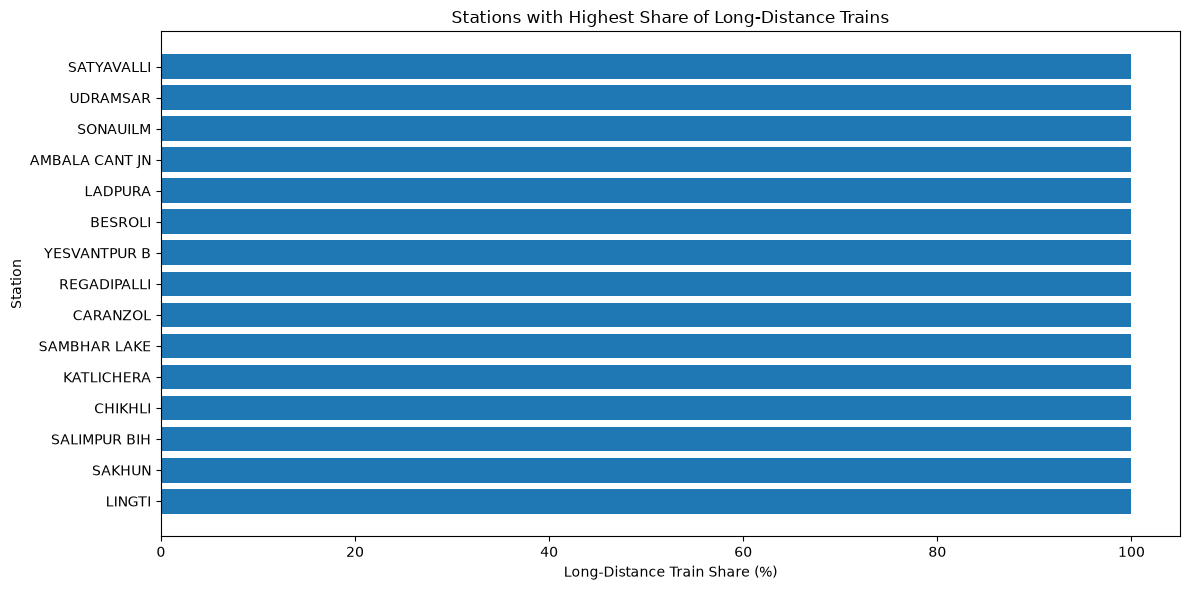

In [144]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_long_route_stations.index,
    top_long_route_stations["Long_Percentage"]
)

plt.title("Stations with Highest Share of Long-Distance Trains")
plt.xlabel("Long-Distance Train Share (%)")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [145]:
longest_routes = (
    train_summary
    .sort_values(
        "Distance",
        ascending=False
    )
    .head(15)
)

longest_routes[
    [
        "Train_No",
        "Distance",
        "Route_Type",
        "Journey_Duration_Hours"
    ]
]

,Train_No,Distance,Route_Type,Journey_Duration_Hours
1934,15905,4260,Long,7.666667
1935,15906,4256,Long,10.750000
36,2515,3939,Long,4.916667
899,12507,3932,Long,2.083333
907,12515,3932,Long,4.583333
908,12516,3930,Long,2.750000
900,12508,3930,Long,2.750000
2021,16317,3769,Long,1.083333
2022,16318,3765,Long,0.000000
2117,16687,3663,Long,22.250000


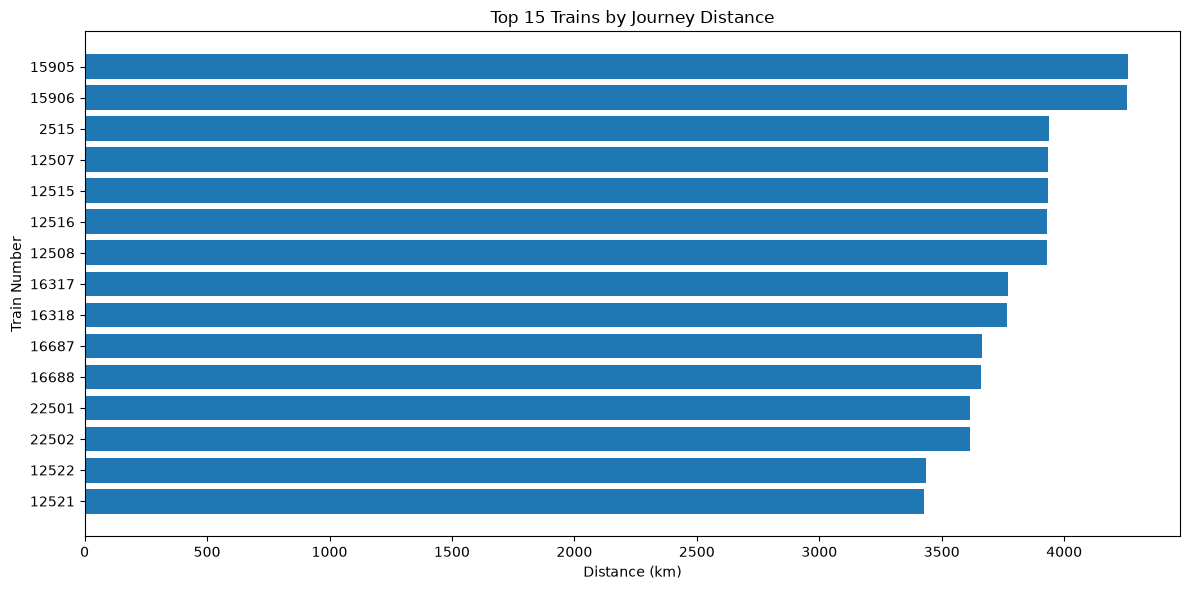

In [146]:
plt.figure(figsize=(12, 6))

plt.barh(
    longest_routes["Train_No"].astype(str),
    longest_routes["Distance"]
)

plt.title("Top 15 Trains by Journey Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Train Number")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [147]:
train_stop_analysis = pd.merge(
    train_summary,
    stops[
        [
            "Train_No",
            "Number_of_Stations",
            "Number_of_Stops"
        ]
    ],
    on="Train_No",
    how="left"
)

train_stop_analysis.head()

,Train_No,Distance,Route_Type,Start_Time,End_Time,Journey_Duration_Hours,Number_of_Stations,Number_of_Stops
0,107,78,Short,1900-01-01 10:25:00,1900-01-01 12:10:00,1.750000,4,3
1,108,83,Short,1900-01-01 20:30:00,1900-01-01 22:25:00,1.916667,4,3
2,128,978,Long,1900-01-01 19:40:00,1900-01-01 17:45:00,22.083333,22,21
3,290,2694,Long,1900-01-01 18:30:00,1900-01-01 02:30:00,8.000000,14,13
4,401,1618,Long,1900-01-01 21:30:00,1900-01-01 10:00:00,12.500000,12,11


In [148]:
top_stop_trains = (
    train_stop_analysis
    .sort_values(
        "Number_of_Stops",
        ascending=False
    )
    .head(15)
)

top_stop_trains[
    [
        "Train_No",
        "Distance",
        "Route_Type",
        "Number_of_Stations",
        "Number_of_Stops",
        "Journey_Duration_Hours"
    ]
]

,Train_No,Distance,Route_Type,Number_of_Stations,Number_of_Stops,Journey_Duration_Hours
5977,53041,718,Long,118,117,5.333333
1348,13007,1949,Long,112,111,21.416667
1372,13049,1908,Long,111,110,20.500000
7383,58112,883,Long,109,108,2.833333
1349,13008,1952,Long,108,107,22.500000
5978,53042,718,Long,107,106,2.833333
1373,13050,1909,Long,106,105,21.583333
7382,58111,885,Long,102,101,0.083333
2431,19019,1676,Long,98,97,17.500000
1483,13352,2534,Long,97,96,7.583333


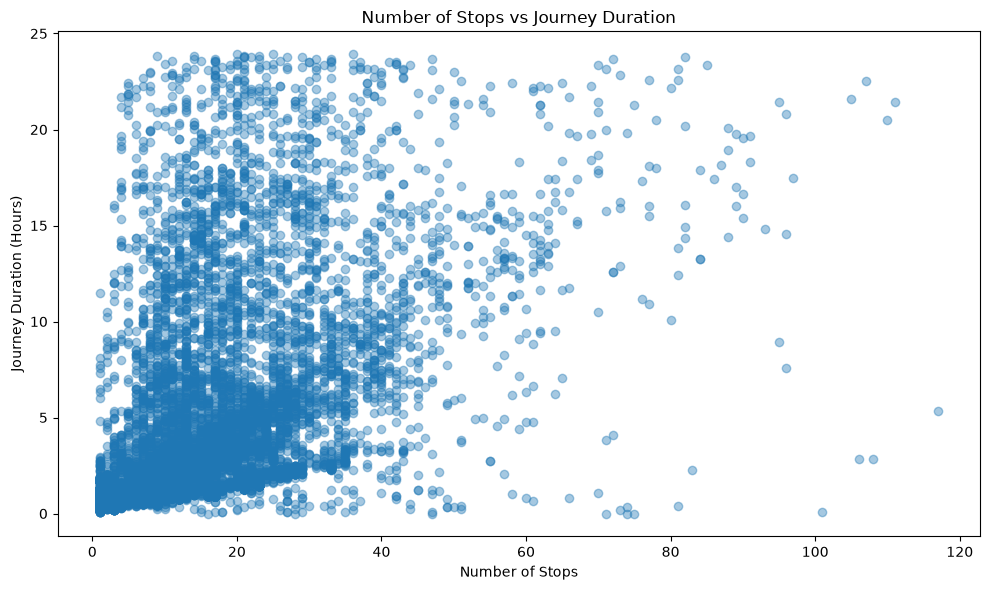

In [149]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_stop_analysis["Number_of_Stops"],
    train_stop_analysis["Journey_Duration_Hours"],
    alpha=0.4
)

plt.title("Number of Stops vs Journey Duration")
plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration (Hours)")

plt.tight_layout()
plt.show()

In [151]:
distance_duration_correlation = (
    train_summary[
        [
            "Distance",
            "Journey_Duration_Hours"
        ]
    ]
    .corr()
)

distance_duration_correlation
correlation_value = (
    train_summary["Distance"]
    .corr(train_summary["Journey_Duration_Hours"])
)

print(
    "Distance vs Journey Duration Correlation:",
    round(correlation_value, 3)
)

Distance vs Journey Duration Correlation: 0.636


In [152]:
avg_stops_by_route = (
    train_stop_analysis
    .groupby("Route_Type")["Number_of_Stops"]
    .mean()
    .reset_index()
)

avg_stops_by_route

,Route_Type,Number_of_Stops
0,Long,25.921506
1,Medium,23.359875
2,Short,11.524122


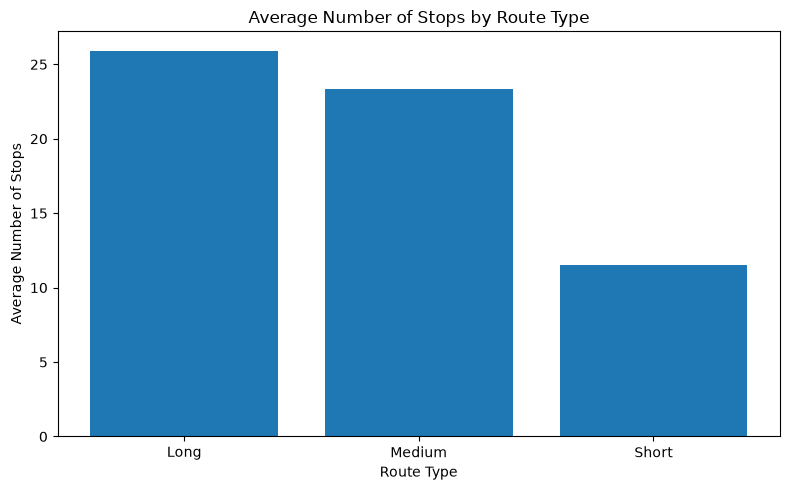

In [153]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_stops_by_route["Route_Type"],
    avg_stops_by_route["Number_of_Stops"]
)

plt.title("Average Number of Stops by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Number of Stops")

plt.tight_layout()
plt.show()

In [154]:
advanced_summary = pd.DataFrame({
    "Metric": [
        "Total Unique Trains",
        "Total Unique Stations",
        "Most Frequent Station",
        "Highest Train Frequency",
        "Longest Journey Distance (km)",
        "Longest Journey Duration (hours)",
        "Average Journey Duration (hours)",
        "Distance-Duration Correlation",
        "Maximum Number of Stops"
    ],
    "Value": [
        train_summary["Train_No"].nunique(),
        df["Station_Name"].nunique(),
        station_frequency.iloc[0]["Station_Name"],
        station_frequency.iloc[0]["Train_Frequency"],
        train_summary["Distance"].max(),
        train_summary["Journey_Duration_Hours"].max(),
        train_summary["Journey_Duration_Hours"].mean(),
        correlation_value,
        train_stop_analysis["Number_of_Stops"].max()
    ]
})

advanced_summary

,Metric,Value
0,Total Unique Trains,11113
1,Total Unique Stations,8099
2,Most Frequent Station,CST-MUMBAI
3,Highest Train Frequency,1027
4,Longest Journey Distance (km),4260
5,Longest Journey Duration (hours),23.916667
6,Average Journey Duration (hours),4.600225
7,Distance-Duration Correlation,0.6357
8,Maximum Number of Stops,117


In [155]:
pivot_station.to_csv(
    "../outputs/tables/station_train_distribution.csv"
)

route_station_crosstab.to_csv(
    "../outputs/tables/station_route_type_crosstab.csv"
)

top_15_stations.to_csv(
    "../outputs/tables/top_15_stations.csv",
    index=False
)

top_long_route_stations.to_csv(
    "../outputs/tables/top_long_route_stations.csv"
)

longest_routes.to_csv(
    "../outputs/tables/longest_routes.csv",
    index=False
)

top_stop_trains.to_csv(
    "../outputs/tables/top_stop_trains.csv",
    index=False
)

train_stop_analysis.to_csv(
    "../outputs/tables/train_stop_analysis.csv",
    index=False
)

avg_stops_by_route.to_csv(
    "../outputs/tables/avg_stops_by_route.csv",
    index=False
)

advanced_summary.to_csv(
    "../outputs/tables/advanced_summary.csv",
    index=False
)

In [156]:
print("LEVEL 5 ADVANCED EDA COMPLETED")
print("--------------------------------")

print("Total Trains:", train_summary["Train_No"].nunique())

print("Total Stations:", df["Station_Name"].nunique())

print(
    "Top Station:",
    station_frequency.iloc[0]["Station_Name"]
)

print(
    "Top Station Train Count:",
    station_frequency.iloc[0]["Train_Frequency"]
)

print(
    "Longest Distance:",
    train_summary["Distance"].max(),
    "km"
)

print(
    "Longest Journey:",
    round(
        train_summary["Journey_Duration_Hours"].max(),
        2
    ),
    "hours"
)

print(
    "Distance-Duration Correlation:",
    round(correlation_value, 3)
)

print(
    "Maximum Stops:",
    int(
        train_stop_analysis["Number_of_Stops"].max()
    )
)

LEVEL 5 ADVANCED EDA COMPLETED
--------------------------------
Total Trains: 11113
Total Stations: 8099
Top Station: CST-MUMBAI
Top Station Train Count: 1027
Longest Distance: 4260 km
Longest Journey: 23.92 hours
Distance-Duration Correlation: 0.636
Maximum Stops: 117


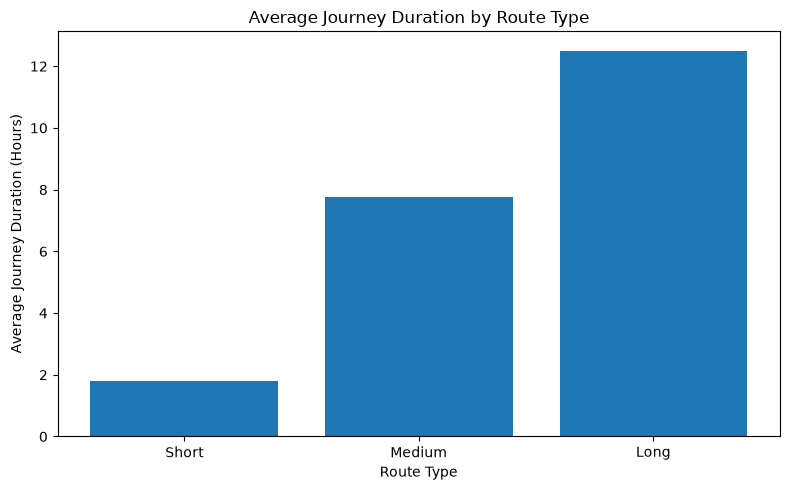

In [157]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_duration_by_route["Route_Type"],
    avg_duration_by_route["Journey_Duration_Hours"]
)

plt.title("Average Journey Duration by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Journey Duration (Hours)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/average_journey_duration_by_route.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

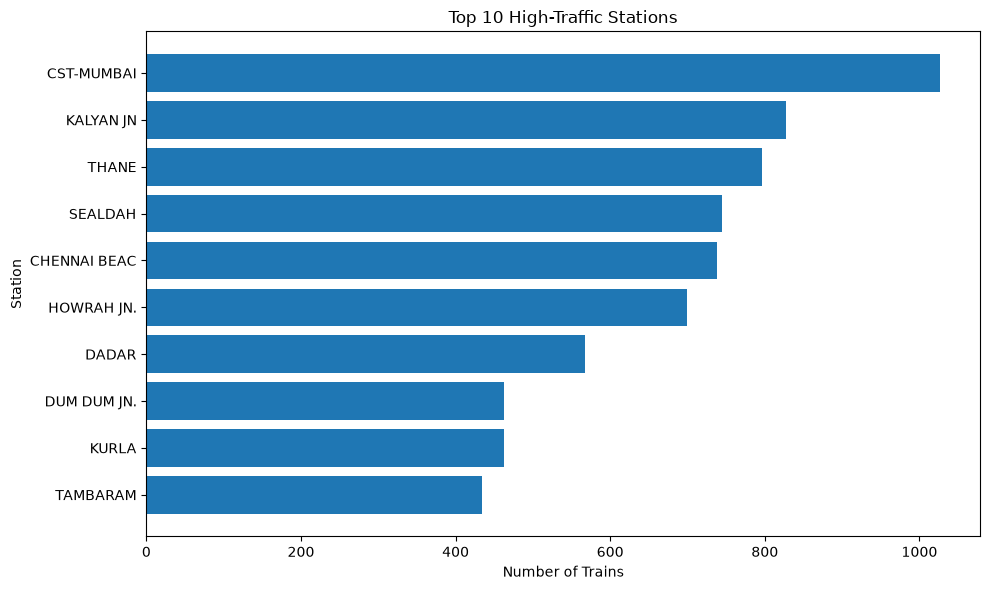

In [158]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_stations["Station_Name"],
    top_stations["Train_Frequency"]
)

plt.title("Top 10 High-Traffic Stations")
plt.xlabel("Number of Trains")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top_10_high_traffic_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

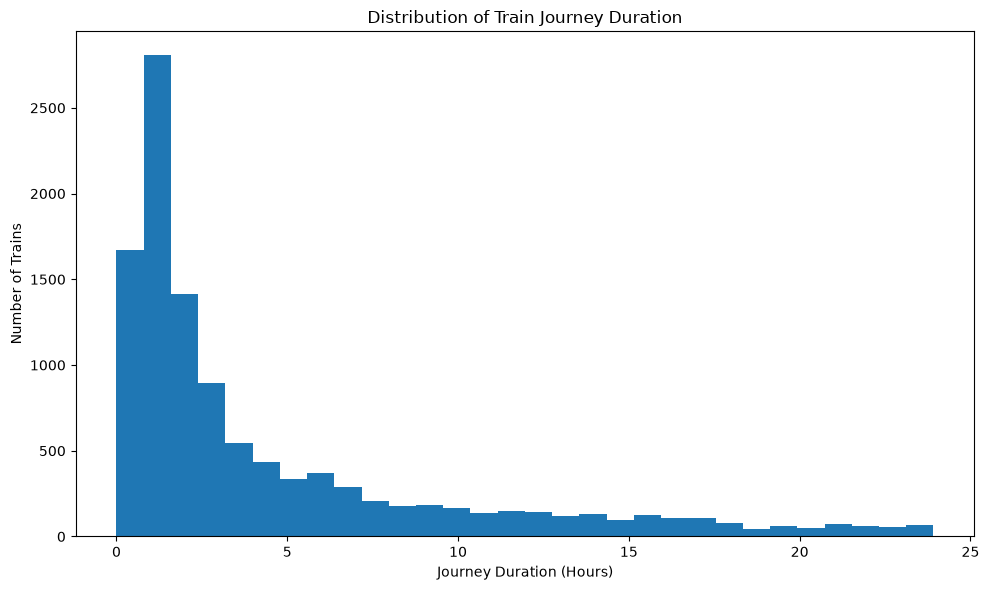

In [159]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_summary["Journey_Duration_Hours"],
    bins=30
)

plt.title("Distribution of Train Journey Duration")
plt.xlabel("Journey Duration (Hours)")
plt.ylabel("Number of Trains")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/journey_duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

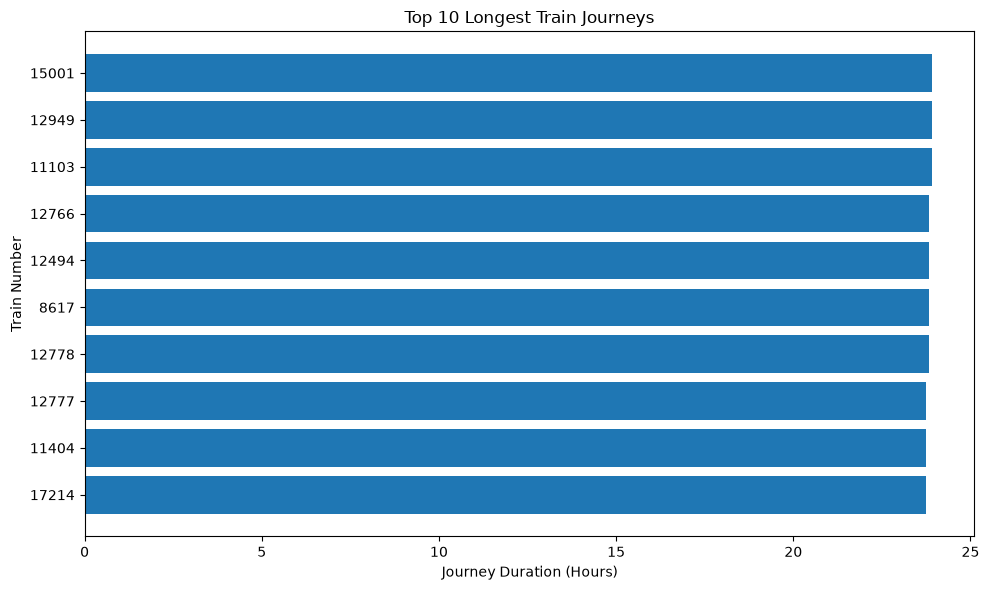

In [160]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_longest_journeys["Train_No"].astype(str),
    top_longest_journeys["Journey_Duration_Hours"]
)

plt.title("Top 10 Longest Train Journeys")
plt.xlabel("Journey Duration (Hours)")
plt.ylabel("Train Number")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top_10_longest_journeys.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

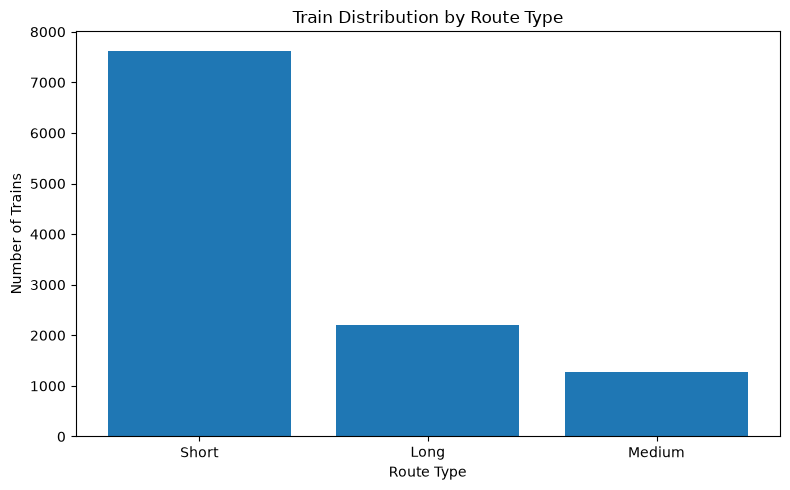

In [161]:
plt.figure(figsize=(8, 5))

plt.bar(
    route_distribution["Route_Type"],
    route_distribution["Train_Count"]
)

plt.title("Train Distribution by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Number of Trains")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/route_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

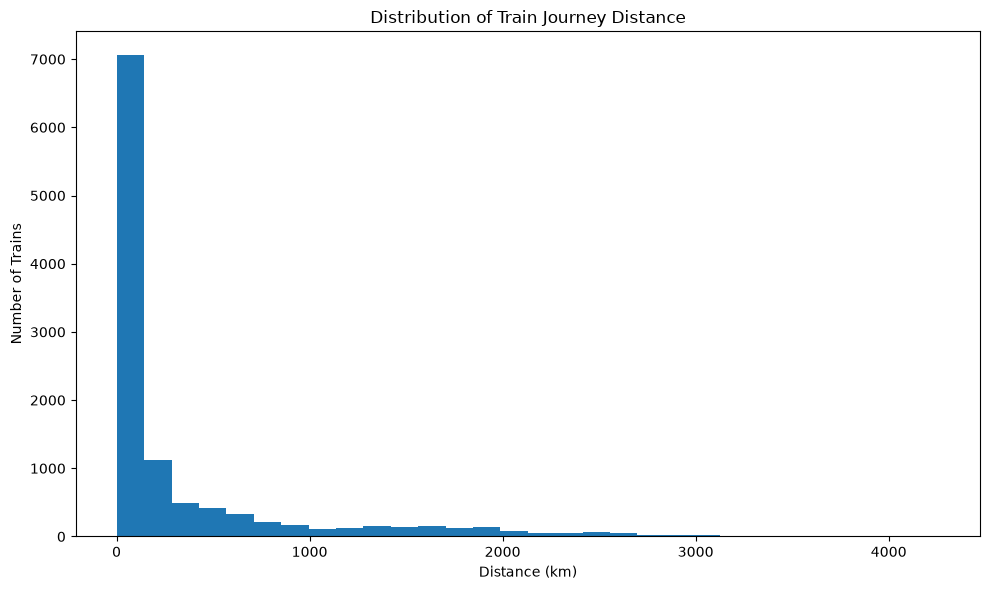

In [162]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_summary["Distance"],
    bins=30
)

plt.title("Distribution of Train Journey Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Trains")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/distance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

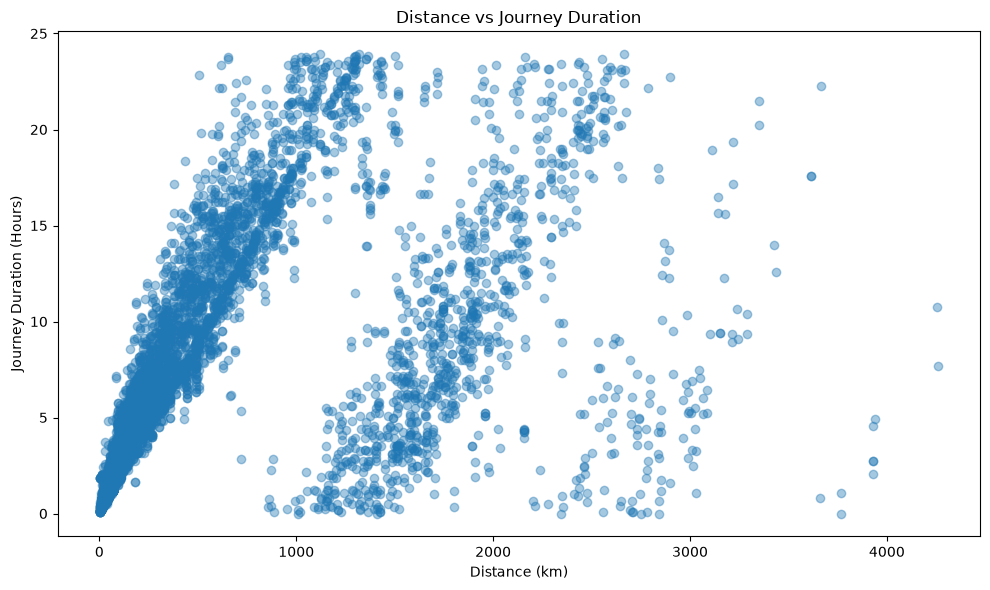

In [163]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_summary["Distance"],
    train_summary["Journey_Duration_Hours"],
    alpha=0.4
)

plt.title("Distance vs Journey Duration")
plt.xlabel("Distance (km)")
plt.ylabel("Journey Duration (Hours)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/distance_vs_journey_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

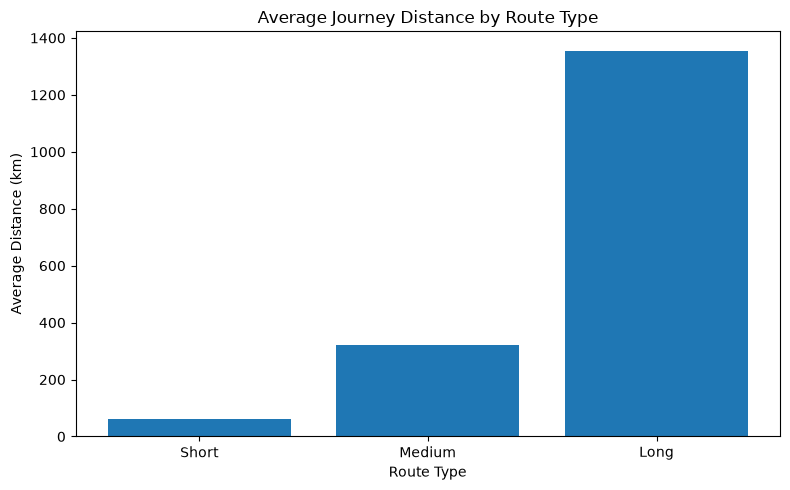

In [164]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_distance_by_route["Route_Type"],
    avg_distance_by_route["Distance"]
)

plt.title("Average Journey Distance by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Distance (km)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/average_distance_by_route.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

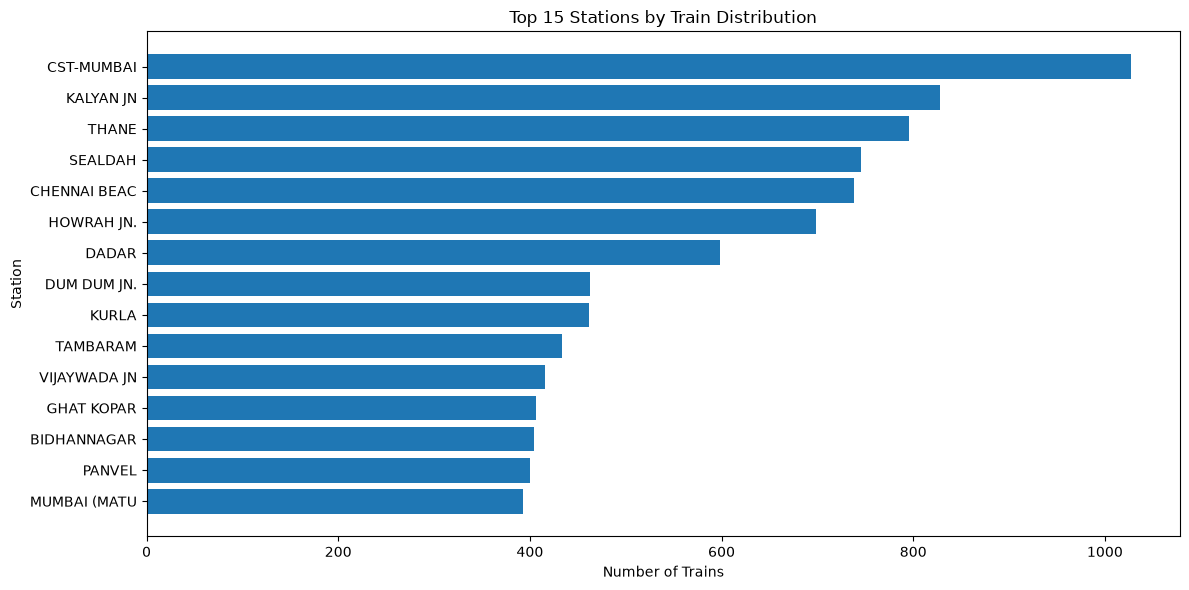

In [165]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_15_stations["Station_Name"],
    top_15_stations["Train_Count"]
)

plt.title("Top 15 Stations by Train Distribution")
plt.xlabel("Number of Trains")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top_15_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

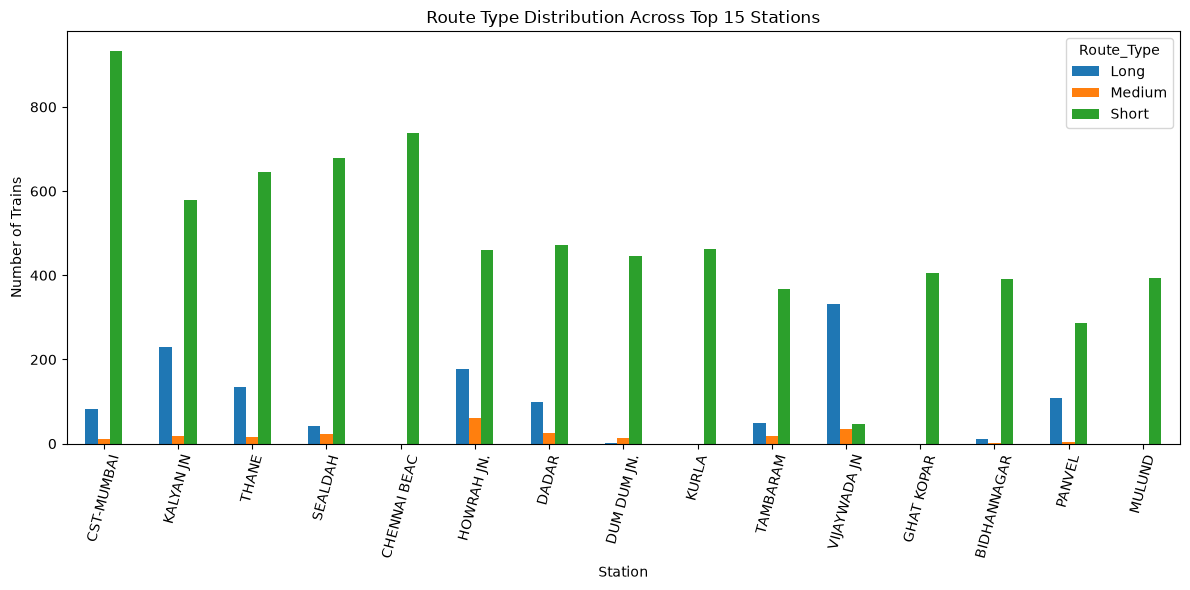

In [166]:
ax = top_15_route_distribution.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Route Type Distribution Across Top 15 Stations")
plt.xlabel("Station")
plt.ylabel("Number of Trains")

plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/route_type_top_15_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

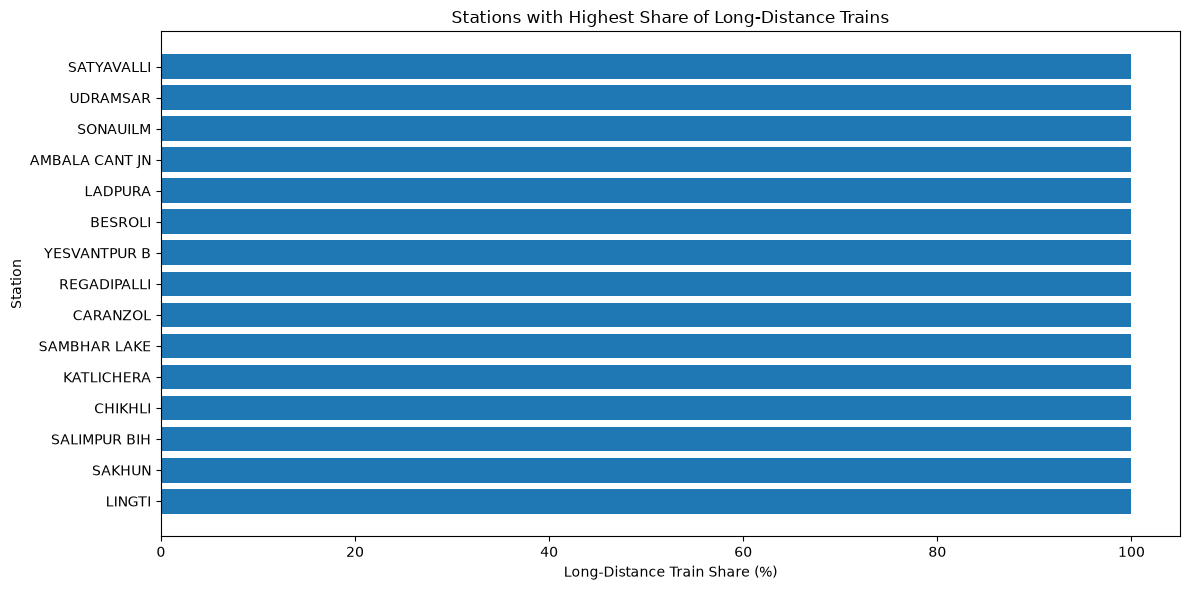

In [167]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_long_route_stations.index,
    top_long_route_stations["Long_Percentage"]
)

plt.title("Stations with Highest Share of Long-Distance Trains")
plt.xlabel("Long-Distance Train Share (%)")
plt.ylabel("Station")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/long_distance_station_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

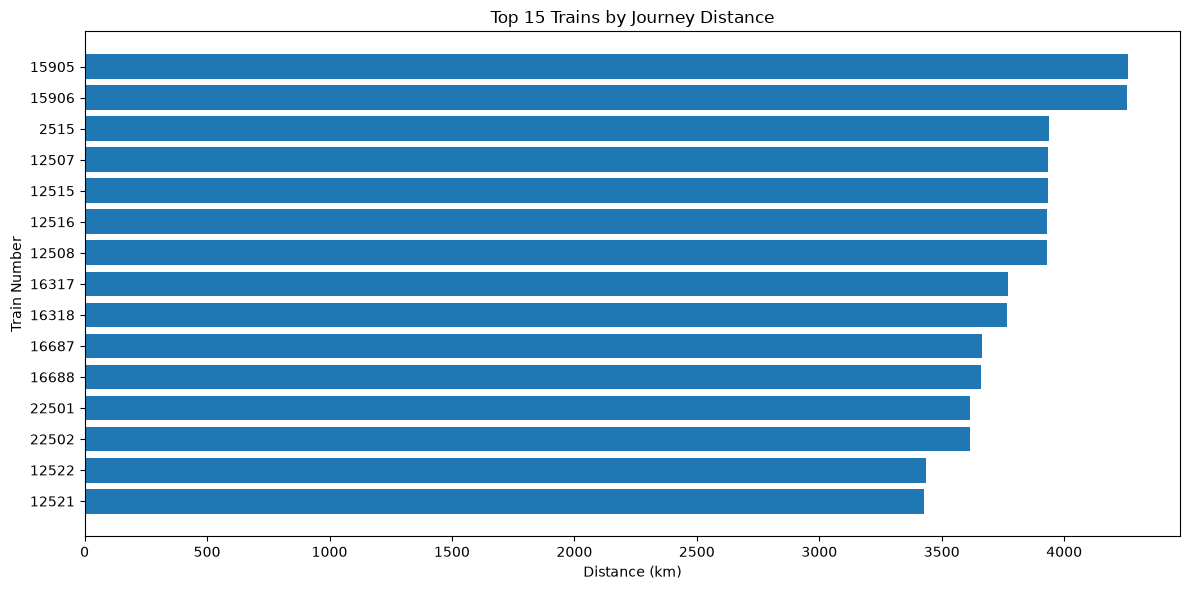

In [168]:
plt.figure(figsize=(12, 6))

plt.barh(
    longest_routes["Train_No"].astype(str),
    longest_routes["Distance"]
)

plt.title("Top 15 Trains by Journey Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Train Number")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top_15_longest_routes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

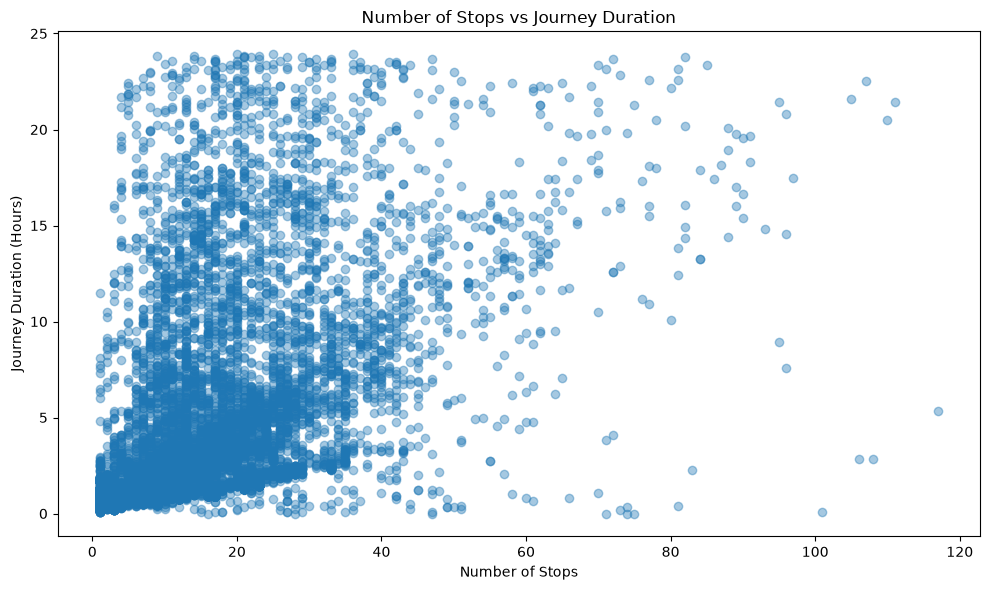

In [169]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_stop_analysis["Number_of_Stops"],
    train_stop_analysis["Journey_Duration_Hours"],
    alpha=0.4
)

plt.title("Number of Stops vs Journey Duration")
plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration (Hours)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/stops_vs_journey_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

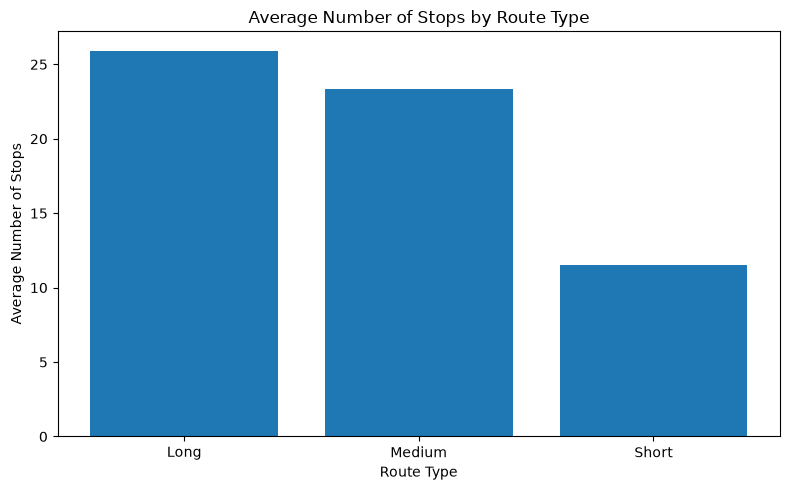

In [170]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_stops_by_route["Route_Type"],
    avg_stops_by_route["Number_of_Stops"]
)

plt.title("Average Number of Stops by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Number of Stops")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/average_stops_by_route.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()